objectif:
Recall au dessus de 80%
Precision au dessus de 50%

Cela nous permet de detecter 80% des fraudes et sur 2 fraudes 1 sera vrai.
Cela reste performant dans le domaine bancaire.
Cela permet egalement de réduire la charge des équipes de recherche de fraude

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/fraudTrain.csv", sep=",")

In [190]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
484076,484076,2019-07-30 19:50:13,180046617132290,fraud_Wilkinson LLC,personal_care,18.64,Erika,Mason,F,083 Karen Island Apt. 656,...,37.5750,-88.9655,3119,"Teacher, secondary school",1942-04-17,25694004a68ac1eaa9d899c8971f8c4e,1343677813,38.222854,-89.341928,0
213659,213659,2019-04-19 10:27:02,565399283797,fraud_Macejkovic-Lesch,shopping_pos,150.66,Anthony,Allen,M,6993 Carr Lodge Apt. 311,...,42.8801,-117.2810,641,Economist,1993-11-24,841593b0e8c965639bfddcdf386d7e7f,1334831222,43.071660,-117.732431,0
248096,248096,2019-05-04 15:21:20,346273234529002,fraud_Metz-Boehm,shopping_pos,40.83,Donna,Moreno,F,32301 Albert River Suite 364,...,37.7418,-80.4626,4575,Statistician,1991-10-22,848e1ba715353db675a8a1cb4b895df7,1336144880,36.771618,-79.885682,0
812265,812265,2019-12-07 13:01:13,2264937662466770,"fraud_Schroeder, Hauck and Treutel",entertainment,34.92,Juan,Sherman,M,5939 Garcia Forges Suite 297,...,29.3641,-98.4924,1595797,Land,1995-10-17,9b0662094ab681f24d9ada3f31935415,1354885273,29.606240,-99.266959,0
446980,446980,2019-07-17 23:07:28,2305336922781618,"fraud_Hodkiewicz, Prohaska and Paucek",travel,9.68,Jeffrey,Rice,M,21447 Powell Circle,...,40.6866,-92.6833,1132,Probation officer,1961-02-14,152d6c6b1b17af1a07af448f29ca9788,1342566448,40.448657,-93.439847,0
26735,26735,2019-01-16 05:31:32,4378993458389626,fraud_Ledner-Pfannerstill,gas_transport,61.23,Travis,Hayes,M,1561 Chase Grove,...,43.9742,-71.1503,3807,Surgeon,1999-10-25,09ed5af9bdf05344e2a20082a03857ff,1326691892,43.206410,-71.548395,0
680586,680586,2019-10-17 14:19:25,378006354724784,fraud_Botsford and Sons,home,73.08,Christopher,Matthews,M,433 John Heights Apt. 849,...,38.5095,-78.2638,395,Senior tax professional/tax inspector,1982-01-07,5a9f2c1c09ce759c101af15e7a1b90cb,1350483565,38.192476,-77.546972,0
477953,477953,2019-07-28 19:58:21,376262134119629,fraud_Fritsch LLC,travel,7.91,Christopher,Carr,M,62931 Ralph Court,...,27.9611,-81.9398,237282,"Radiographer, therapeutic",1961-09-28,76d14447d1f0f6aa2a5c8c05a504361a,1343505501,28.081748,-81.768429,0
298982,298982,2019-05-26 10:34:47,6011381817520024,fraud_Bailey-Morar,grocery_pos,83.15,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,49a28b6559b4a545196378969321acef,1338028487,41.162274,-105.117515,0
1240742,1240742,2020-06-01 13:07:56,4319584480204988982,fraud_Wuckert-Goldner,home,66.18,Kathleen,Nash,F,010 Salazar Walk,...,37.1788,-82.6950,502,Chief Financial Officer,1960-02-01,e820b7c573734a56e9ea255593838925,1370092076,38.172922,-82.920492,0


In [191]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

On constate qu'on a un dataset très deséquilibrer

In [192]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

<Axes: ylabel='count'>

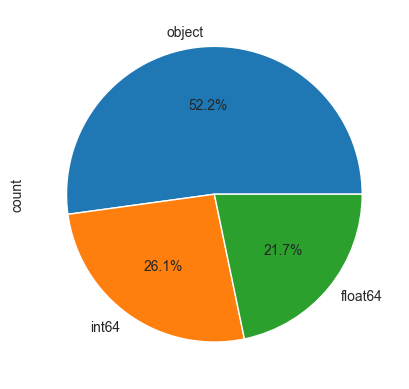

In [193]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

On constate qu'il y a beaucoup de colonne de type object

In [194]:
print(df.duplicated().sum().sum())

0


In [195]:
df.describe(include="all")

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,...,NaN,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


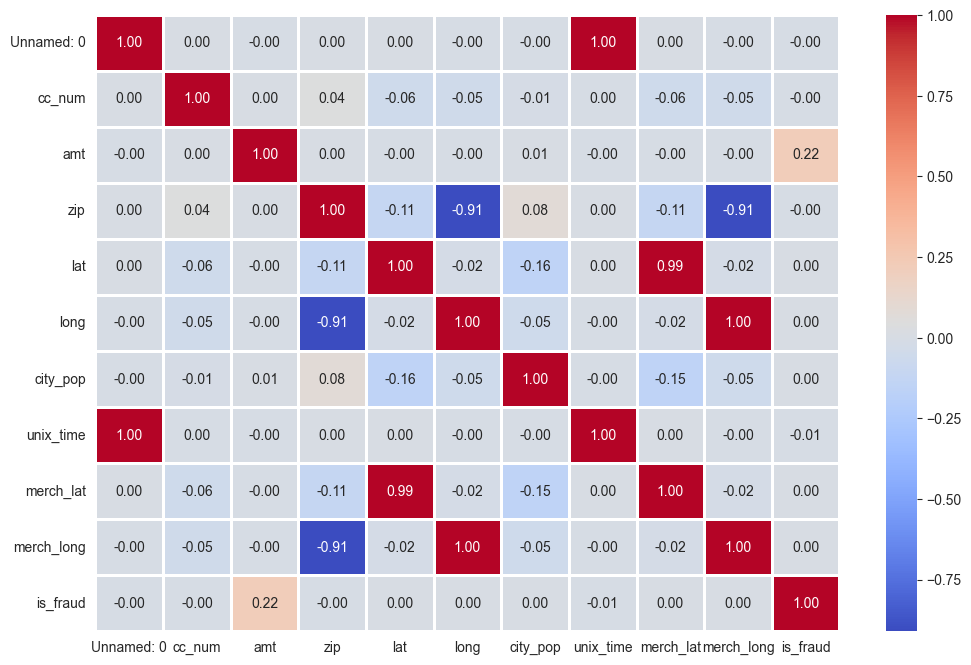

In [196]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [197]:
df.drop(["merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first'], axis=1, inplace=True)

In [198]:
df.describe(include='all')

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,is_fraud
count,1296675,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1.296675e+06,1.296675e+06
unique,1274791,693,14,NaN,2,983,894,51,NaN,NaN,494,968,NaN,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN,NaN
freq,4,4403,131659,NaN,709863,3123,5617,94876,NaN,NaN,9779,5636,NaN,NaN
mean,NaN,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,1.349244e+09,5.788652e-03
std,NaN,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,1.284128e+07,7.586269e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,1.325376e+09,0.000000e+00
25%,NaN,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,1.338751e+09,0.000000e+00
50%,NaN,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,1.349250e+09,0.000000e+00
75%,NaN,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,1.359385e+09,0.000000e+00


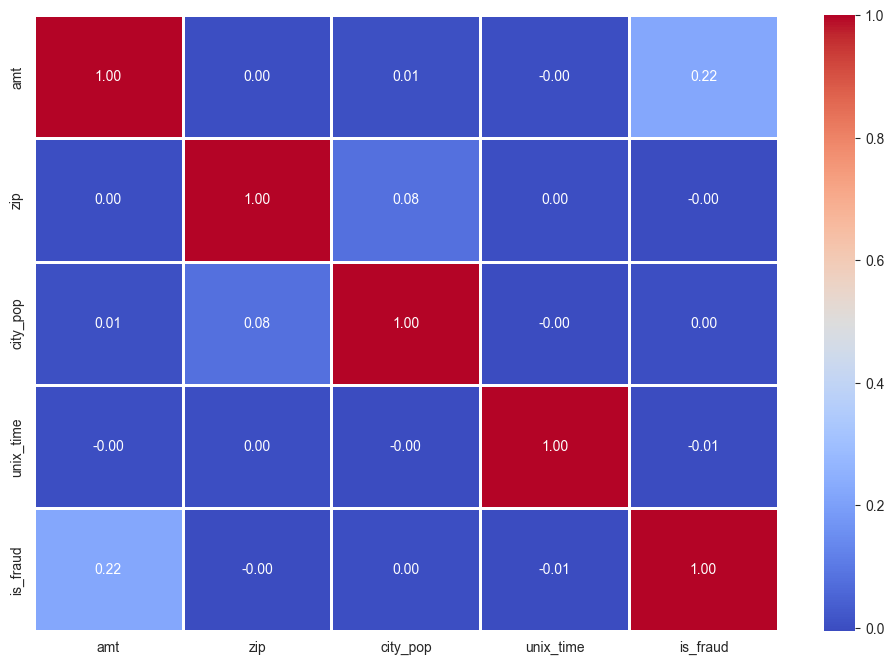

In [199]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [200]:
df.sample(5)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,unix_time,is_fraud
421662,2019-07-08 13:53:44,fraud_Cormier LLC,shopping_net,4.67,M,97070 Anderson Land,Haines City,FL,33844,33804,Exercise physiologist,1991-01-01,1341755624,0
1042249,2020-03-08 15:35:16,fraud_Cormier LLC,health_fitness,73.23,M,70147 Amanda Fields,Saint Bonaventure,NY,14778,1453,Toxicologist,1974-02-15,1362756916,0
719145,2019-11-03 11:47:45,"fraud_Heller, Gutmann and Zieme",grocery_pos,95.46,F,329 Emily Cape,Cape Coral,FL,33909,156391,Higher education careers adviser,1968-02-09,1351943265,0
48316,2019-01-29 05:53:36,fraud_Morar Inc,grocery_net,52.44,F,08932 Bonnie Stravenue,Bonita Springs,FL,34135,51427,Claims inspector/assessor,1991-08-21,1327816416,0
875305,2019-12-21 13:08:09,"fraud_Stanton, Jakubowski and Baumbach",shopping_net,4.17,F,118 Cabrera Springs Apt. 105,Lanark Village,FL,32323,217,Television production assistant,1990-01-24,1356095289,0


# Pretraitement

In [201]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [202]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_transaction, Length: 1296675, dtype: int64

<Axes: ylabel='Frequency'>

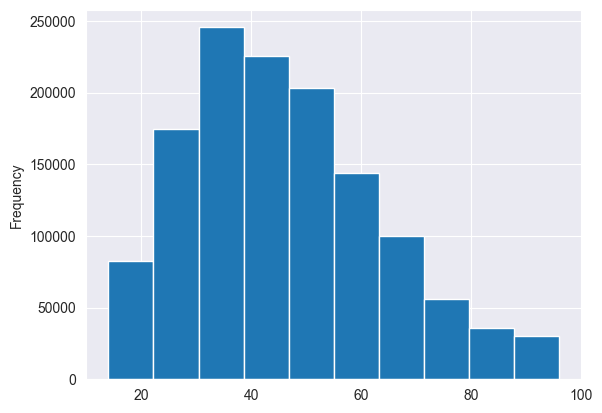

In [203]:
df['age_at_transaction'].plot(kind='hist')

In [204]:
df.drop(["dob","trans_date_trans_time"], axis=1, inplace=True)

In [205]:
df.columns

Index(['merchant', 'category', 'amt', 'gender', 'street', 'city', 'state',
       'zip', 'city_pop', 'job', 'unix_time', 'is_fraud',
       'age_at_transaction'],
      dtype='object')

In [206]:
df.sample(4)

,merchant,category,amt,gender,street,city,state,zip,city_pop,job,unix_time,is_fraud,age_at_transaction
1175479,fraud_Barrows PLC,shopping_pos,4.17,M,0005 Morrison Land,Mounds,OK,74047,7163,Fitness centre manager,1367762988,0,38
1139996,fraud_Bogisich-Homenick,misc_net,3.89,F,4503 Patricia Route,Meridian,ID,83646,84106,Intelligence analyst,1366437333,0,49
292188,fraud_Denesik and Sons,shopping_pos,6.40,M,69085 Short Shores,Allentown,NY,14707,239,Radio producer,1337820246,0,63
117994,fraud_Beier-Hyatt,shopping_pos,7.35,F,3645 Atkins Island Apt. 238,Esbon,KS,66941,242,Tourism officer,1331157850,0,32


In [207]:
y = df["is_fraud"].astype(int)
X = df.drop(columns=["is_fraud"])

In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ✅ stratification sur la cible
)

In [209]:
numeric_features = ["amt","zip", "city_pop", "age_at_transaction","unix_time"]
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        #("cat_ord", categorical_ord_transformer, categorical_features_ord),
        ("cat_non_ord", categorical_non_ord_transformer, categorical_features_non_ord),
    ],
    remainder="drop"
)

# Machine Learning

In [210]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve

In [211]:
model_xgb = XGBClassifier(
        # --- Accélération Matérielle ---
    tree_method='hist',
    device='cuda:0',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=10,            # ratio 99% / 1%
    subsample=0.8,                  # Sous-échantillonnage des lignes
    colsample_bytree=0.8,           # Sous-échantillonnage des colonnes
    eval_metric='aucpr',            # Optimise pour la précision-rappel
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_xgb)
])

In [212]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'city_pop',
                                                   'age_at_transaction',
                                                   'unix_time']),
                                                 ('cat_non_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinay',
                                                                   OrdinalEncoder())]),
                                                  ['state', 'city', '...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [213]:
X_train

,merchant,category,amt,gender,street,city,state,zip,city_pop,job,unix_time,age_at_transaction
509059,"fraud_Stokes, Christiansen and Sipes",grocery_net,51.71,F,79472 Stevens Trace Apt. 120,Hannawa Falls,NY,13647,69,Chief Executive Officer,1344482007,28
395295,fraud_Effertz LLC,entertainment,13.78,F,554 Mcdonald Valley Apt. 539,Meridian,TX,76665,2526,Phytotherapist,1340999808,49
536531,fraud_Kris-Padberg,shopping_pos,961.26,F,7202 Jeffrey Mills,Conway,WA,98238,85,"Research officer, political party",1345300940,35
271001,fraud_Ratke and Sons,health_fitness,43.68,M,5758 Yates Center,Vinton,CA,96135,128,Education administrator,1336944466,53
532788,fraud_Upton PLC,entertainment,33.08,F,852 Thomas Well Suite 339,Owensville,MO,65066,6703,Naval architect,1345212941,21
...,...,...,...,...,...,...,...,...,...,...,...,...
125527,"fraud_Effertz, Welch and Schowalter",entertainment,19.70,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,1331413575,34
150047,fraud_Pacocha-Bauch,shopping_pos,123.45,M,495 Fisher Throughway,Grand Junction,TN,38039,1804,Clothing/textile technologist,1332392799,44
1151888,fraud_Abernathy and Sons,food_dining,64.98,F,55363 Aaron Circle Suite 450,Lawn,PA,17041,213,Special educational needs teacher,1366913512,48
547306,fraud_Windler LLC,kids_pets,33.65,M,01479 Murray Circle,Matawan,NJ,7747,30770,Drilling engineer,1345647578,26


In [214]:
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

D:\Etude\Master cours\NLP\NLP_python\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [08:00:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9953
F1-score:  0.6764

Confusion matrix:
 [[256838    996]
 [   225   1276]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.56      0.85      0.68      1501

    accuracy                           1.00    259335
   macro avg       0.78      0.92      0.84    259335
weighted avg       1.00      1.00      1.00    259335



In [215]:
X_train.columns

Index(['merchant', 'category', 'amt', 'gender', 'street', 'city', 'state',
       'zip', 'city_pop', 'job', 'unix_time', 'age_at_transaction'],
      dtype='object')

In [216]:
column_names = preprocessor.get_feature_names_out()
# 2. On crée la Series avec ces noms
feat_importances = pd.Series(model_xgb.feature_importances_, index=column_names).sort_values(ascending=False)
print(feat_importances)

num__amt                   0.553974
cat_non_ord__category      0.195756
cat_non_ord__gender        0.054682
num__age_at_transaction    0.040716
num__city_pop              0.027923
num__unix_time             0.026852
cat_non_ord__job           0.022626
cat_non_ord__city          0.022142
num__zip                   0.020853
cat_non_ord__state         0.020195
cat_non_ord__merchant      0.014283
dtype: float32


In [217]:
y_probs = pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recall, precision)
print(pr_auc)

0.8277516800051724


In [218]:
import joblib

# Sauvegarder sur le disque
joblib.dump(pipe, 'model_fraude_xgboost_final_2.pkl')

print("Modèle complet sauvegardé sous 'model_fraude_xgboost_final.pkl'")

Modèle complet sauvegardé sous 'model_fraude_xgboost_final.pkl'


Rechercher des meilleures hyper parametre avec RandomizedSearchCV

In [221]:
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.model_selection import RandomizedSearchCV
# Configuration de la validation croisée (essentiel pour le 1% de fraude)

# Définition de la grille de recherche
# Note : on utilise 'model__' car c'est le nom dans ta pipeline
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__scale_pos_weight': [10, 50, 99],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8],
    'model__min_child_weight': [1, 5]
}

# Scoring axé sur la précision/rappel (AUPRC)
auprc_scorer = make_scorer(average_precision_score, response_method='predict_proba')
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid, # On garde la même grille
    n_iter=30,                     # On limite à 30 combinaisons au lieu de 162
    scoring=auprc_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,                      # Toujours 1 pour le GPU
    random_state=42
)

# Total fits : 30 itérations * 5 folds = 150 fits (au lieu de 810 !)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=99, model__subsample=0.8; total time=   5.4s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=99, model__subsample=0.8; total time=   6.3s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=99, model__subsample=0.8; total time=   5.3s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__n_estimators=200, model__scale_pos_weight=99, model__subsample=0.8; total time=   5.4s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=5, model__

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['amt',
                                                                                'zip',
                                                                                'city_pop',
                                                                                'age_at_transaction',
                                                                                'unix_time']),
                                                                              ('cat_non_ord',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ordinay',
                                                                                                Ord...
                   param_distributions={'model__colsample_bytree': [0.8],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5],
                                        'model__min_child_weight': [1, 5],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__scale_pos_weight': [10, 50, 99],
                                        'model__subsample': [0.8]},
                   random_state=42,
                   scoring=make_scorer(average_precision_score, response_method='predict_proba'),
                   verbose=2)

In [222]:
# Le meilleur modèle complet (avec preprocessing + meilleurs hyperparamètres)
best_pipeline = random_search.best_estimator_

# Afficher les meilleurs réglages
print("Meilleurs paramètres trouvés :", random_search.best_params_)

Meilleurs paramètres trouvés : {'model__subsample': 0.8, 'model__scale_pos_weight': 10, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [245]:
# Evaluation du modele optimise
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Accuracy: {acc_best:.4f}")
print(f"F1-score: {f1_best:.4f}")

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
pr_auc_best = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"PR-AUC: {pr_auc_best:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best))

Accuracy: 0.9954
F1-score: 0.6798
ROC-AUC: 0.9964
PR-AUC: 0.8303

Confusion matrix:
 [[256859    975]
 [   226   1275]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.57      0.85      0.68      1501

    accuracy                           1.00    259335
   macro avg       0.78      0.92      0.84    259335
weighted avg       1.00      1.00      1.00    259335



In [246]:
for i in np.arange(0.1, 1, 0.1):
    # 2. Appliquer le nouveau seuil de detection d'une fraude
    threshold = i
    y_pred_custom = (y_pred_proba_best >= threshold).astype(int)

    # 3. Afficher le nouveau rapport
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"--- RAPPORT AVEC SEUIL {threshold:.1f} ---")
    print(classification_report(y_test, y_pred_custom))

--- RAPPORT AVEC SEUIL 0.1 ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.22      0.95      0.36      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.97      0.68    259335
weighted avg       1.00      0.98      0.99    259335

--- RAPPORT AVEC SEUIL 0.2 ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.37      0.91      0.53      1501

    accuracy                           0.99    259335
   macro avg       0.69      0.95      0.76    259335
weighted avg       1.00      0.99      0.99    259335

--- RAPPORT AVEC SEUIL 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.47      0.89      0.61      1501

    accuracy                           0.99    259335
   macro avg       0.73      0.94  

On teste un deuxieme modème Random forest

In [238]:
# Modele 2: Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight={0: 1, 1: 100},  # gere le desequilibre
    random_state=42,
    n_jobs=-1  # utilise tous les coeurs CPU
)

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_rf)
])

pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'city_pop',
                                                   'age_at_transaction',
                                                   'unix_time']),
                                                 ('cat_non_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinay',
                                                                   OrdinalEncoder())]),
                                                  ['state', 'city', 'gender',
                                                   'category', 'merchant',
                                                   'job'])])),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 100},
                                        max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [242]:
# Evaluation Random Forest
y_pred_rf = pipe_rf.predict(X_test)
y_pred_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC: {pr_auc_rf:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9908
F1-score: 0.5175
ROC-AUC: 0.9915
PR-AUC: 0.7327

Confusion matrix:
 [[255651   2183]
 [   215   1286]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.37      0.86      0.52      1501

    accuracy                           0.99    259335
   macro avg       0.68      0.92      0.76    259335
weighted avg       1.00      0.99      0.99    259335



Accuracy: 0.9908
F1-score: 0.5175
ROC-AUC: 0.9915
PR-AUC: 0.7327

Confusion matrix:
 [[255651   2183]
 [   215   1286]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.37      0.86      0.52      1501

    accuracy                           0.99    259335
   macro avg       0.68      0.92      0.76    259335
weighted avg       1.00      0.99      0.99    259335



Modele ILIES
Accuracy: 0.9822
F1-score: 0.3676
ROC-AUC: 0.9922
PR-AUC: 0.7218

Confusion matrix:
 [[253362   4472]
 [   156   1345]]


In [243]:
# 1. Obtenir les probabilités au lieu des classes (0 ou 1)
# predict_proba renvoie deux colonnes : [probabilité de 0, probabilité de 1]

for i in np.arange(0.1, 1, 0.1):
    # 2. Appliquer le nouveau seuil de 0.3
    threshold = i
    y_pred_custom = (y_pred_proba_rf >= threshold).astype(int)

    # 3. Afficher le nouveau rapport
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"--- RAPPORT AVEC SEUIL {threshold:.1f} ---")
    print(classification_report(y_test, y_pred_custom))

--- RAPPORT AVEC SEUIL 0.1 ---
              precision    recall  f1-score   support

           0       1.00      0.78      0.88    257834
           1       0.03      1.00      0.05      1501

    accuracy                           0.78    259335
   macro avg       0.51      0.89      0.46    259335
weighted avg       0.99      0.78      0.87    259335

--- RAPPORT AVEC SEUIL 0.2 ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    257834
           1       0.07      0.97      0.13      1501

    accuracy                           0.93    259335
   macro avg       0.54      0.95      0.55    259335
weighted avg       0.99      0.93      0.96    259335

--- RAPPORT AVEC SEUIL 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    257834
           1       0.15      0.92      0.26      1501

    accuracy                           0.97    259335
   macro avg       0.57      0.95  

In [248]:
# Sa prend beaucoup de temps la recherche des meilleure hyper parametre
"""param_grid_model_rf = {
    # On évite 'None' qui peut faire exploser la RAM sur 1.2M de lignes
    'model__max_depth': [10, 20, 30],
    # 500 arbres c'est lent, 100 et 200 suffisent souvent pour trouver les bons hyperparamètres
    'model__n_estimators': [100, 200,300],
    # On mise tout sur le rééquilibrage
    'model__class_weight': ['balanced_subsample', {0: 1, 1: 100}, {0: 1, 1: 200},{0: 1, 1: 250}],
    # On garde les valeurs standards
    'model__max_features': ['sqrt', 0.8],
    # On simplifie pour limiter le nombre de modèles
    'model__min_samples_leaf': [1,2,4],
    'model__bootstrap': [True]
}

# Scoring axé sur la précision/rappel (AUPRC)
auprc_scorer_model_rf = make_scorer(average_precision_score, response_method='predict_proba')
random_search_model_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_grid_model_rf, # On garde la même grille
    n_iter=15,                     # On limite à 30 combinaisons au lieu de 162
    scoring=auprc_scorer_model_rf,
    cv=3,
    verbose=2,
    n_jobs=-1,                      # Toujours 1 pour le GPU
    random_state=42
)


random_search_model_rf.fit(X_train, y_train)"""

"param_grid_model_rf = {\n    # On évite 'None' qui peut faire exploser la RAM sur 1.2M de lignes\n    'model__max_depth': [10, 20, 30],\n    # 500 arbres c'est lent, 100 et 200 suffisent souvent pour trouver les bons hyperparamètres\n    'model__n_estimators': [100, 200,300],\n    # On mise tout sur le rééquilibrage\n    'model__class_weight': ['balanced_subsample', {0: 1, 1: 100}, {0: 1, 1: 200},{0: 1, 1: 250}],\n    # On garde les valeurs standards\n    'model__max_features': ['sqrt', 0.8],\n    # On simplifie pour limiter le nombre de modèles\n    'model__min_samples_leaf': [1,2,4],\n    'model__bootstrap': [True]\n}\n\n# Scoring axé sur la précision/rappel (AUPRC)\nauprc_scorer_model_rf = make_scorer(average_precision_score, response_method='predict_proba')\nrandom_search_model_rf = RandomizedSearchCV(\n    estimator=pipe_rf,\n    param_distributions=param_grid_model_rf, # On garde la même grille\n    n_iter=15,                     # On limite à 30 combinaisons au lieu de 162\n   

In [247]:
# Modele 3: Logistic Regression
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_lr)
])

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'city_pop',
                                                   'age_at_transaction',
                                                   'unix_time']),
                                                 ('cat_non_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinay',
                                                                   OrdinalEncoder())]),
                                                  ['state', 'city', 'gender',
                                                   'category', 'merchant',
                                                   'job'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, random_state=42))])

In [39]:
# Evaluation Logistic Regression
y_pred_lr = pipe_lr.predict(X_test)
y_pred_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc_lr = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.9488
F1-score: 0.1468
ROC-AUC: 0.8555
PR-AUC: 0.2029

Confusion matrix:
 [[244919  12915]
 [   359   1142]]


In [ ]:
print("\nClassification report:\n", classification_report(y_test, y_pred_lr))

In [40]:
# Comparaison des 3 modeles supervises
import pandas as pd

resultats = pd.DataFrame({
    'Modele': ['XGBoost (optimise)', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [acc_best, acc_rf, acc_lr],
    'F1-Score': [f1_best, f1_rf, f1_lr],
    'ROC-AUC': [roc_auc_best, roc_auc_rf, roc_auc_lr],
    'PR-AUC': [pr_auc_best, pr_auc_rf, pr_auc_lr]
})

print(resultats.to_string(index=False))

             Modele  Accuracy  F1-Score  ROC-AUC   PR-AUC
 XGBoost (optimise)  0.992677  0.513949 0.946799 0.538504
      Random Forest  0.982154  0.367587 0.992233 0.721811
Logistic Regression  0.948815  0.146806 0.855536 0.202871


In [41]:
# Test avec SMOTE pour gerer le desequilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Pipeline avec SMOTE
model_xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)

pipe_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", model_xgb_smote)
])

pipe_smote.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_non_ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

In [42]:
# Evaluation XGBoost avec SMOTE
y_pred_smote = pipe_smote.predict(X_test)
y_pred_proba_smote = pipe_smote.predict_proba(X_test)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"Accuracy: {acc_smote:.4f}")
print(f"F1-score: {f1_smote:.4f}")

roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_smote)
pr_auc_smote = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_smote:.4f}")
print(f"PR-AUC: {pr_auc_smote:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_smote))

Accuracy: 0.9611
F1-score: 0.1854
ROC-AUC: 0.8959
PR-AUC: 0.4050

Confusion matrix:
 [[248109   9725]
 [   354   1147]]
